### Importing Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sympy.printing.pretty.pretty_symbology import line_width

In [2]:
import statsmodels.api as sm

In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

### Simple Linear Regression

In [4]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [5]:
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


* `sm.OLS()` for fitting a simple linear regression model.
* `medv` will be our _response variable_.
* `lstat` will be our _predictor variable_.

model will be:

**medv** = beta_O _+_ (beta_1 _*_ **lstat**)

In [6]:
X = pd.DataFrame({"intercept": np.ones(Boston.shape[0]),
                  "lstat": Boston["lstat"]})

In [7]:
X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


In [8]:
y = Boston["medv"]

In [9]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

In [10]:
model = sm.OLS(y, X) # sm.OLS() specifies the model
results = model.fit() # model.fit() does the actual fitting

In [11]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


### Building the Model Matrix

A model matrix (also called a design matrix) is a mathematically structured table used in statistics and machine learning to fit regression models. It transforms raw data—especially text labels and categories—into a clean grid of pure numbers that mathematical algorithms can understand.

In [12]:
design = MS(["lstat"])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


1. The `fit` Part (Inspecting the Data)

    The function opens up the Boston dataframe to inspect the "lstat" column. It checks:

    * Does a column named "lstat" actually exist in this dataframe?

    * Is it a numerical column or a categorical column? (If it were categorical, fit would note down all the unique categories to create dummy variables later).

2. The `transform` Part (Building the Matrix)

   Once it understands the structure of the column, it pulls the actual data values out of the Boston dataframe. It then couples those values with a column of 1s to build and return the final mathematical design matrix ($X$).

In [13]:
# The upper code can also be written as:
design = MS(["lstat"])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


### Back to the fitted regression model

In [14]:
results.summary() # gives the exhaustive summary of our fitted model

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           5.08e-88
Time:                        14:06:44   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [16]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


### Working on the prediction data

`get_prediction()` method is used for obtaining the predictions, and produce confidence intervals and prediction intervals for the prediction of `medv` for given values of `lstat`.

In [17]:
new_df = pd.DataFrame({"lstat": [5, 10, 15]})
# for passing our newly prepared prediction data (testing data) we have to transform our data exactly in the format of our fitted model's dataframe.
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [18]:
# as the prediction data is transformed we are going to compute the predictions on that variable

new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [19]:
# confidence intervals

new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [20]:
# prediction intervals

new_predictions.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

### Plotting of the regression fit of our model

In [21]:
# defining functions

def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"

    xlim = ax.get_xlim() # limit points of the x-axis of our data represented as: (min, max)
    ylim = [m * xlim[0] + b, m * xlim[1] + b] # limit points of the y-axis of the regression line represented as: (min, max)
    ax.plot(xlim, ylim, *args, **kwargs)


C:\Users\AAYUSH OJHA\AppData\Local\Temp\ipykernel_20272\3300200112.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0], # intercept
C:\Users\AAYUSH OJHA\AppData\Local\Temp\ipykernel_20272\3300200112.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1], # slope


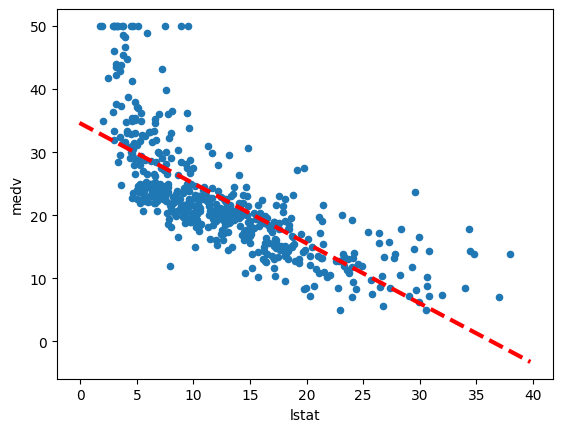

In [22]:
ax = Boston.plot.scatter("lstat", "medv")
abline(ax,
       results.params[0], # intercept
       results.params[1], # slope
       "r--",
       linewidth=3)

# could also be done by using the "ax.axline()"

### Residual Plot

we can find the fitted values and residuals of the fit as attributes of the `results` object.

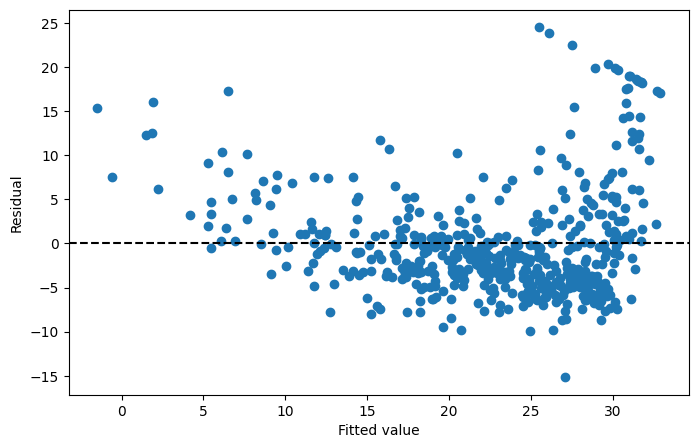

In [23]:
# residual plot

ax = plt.subplots(figsize=(8,5))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.axhline(0, c="k", ls="--")

### Leverage Plot

np.int64(374)

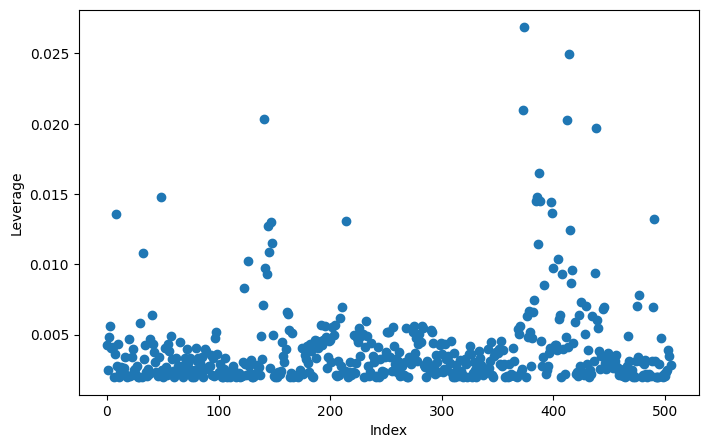

In [24]:
inf1 = results.get_influence()
fig, ax = plt.subplots(figsize = (8,5))
ax.scatter(np.arange(X.shape[0]), inf1.hat_matrix_diag)
ax.set_xlabel("Index")
ax.set_ylabel("Leverage")
np.argmax(inf1.hat_matrix_diag) # identifies the index of the largest element of the array, optionally computed over an axis of the array.
# in this case we maximised over the entire array to determine which observation has the largest leverage statistics.

## Efficient code for our data

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize

# 1. Load data
boston = load_data("Boston")

# 2. Build design matrix and fit the model efficiently
design = MS(["lstat"])
X = design.fit_transform(boston)
y = boston["medv"]

results = sm.OLS(y, X).fit()
print(summarize(results))

# 3. Create new data and predict in one go
new_df = pd.DataFrame({"lstat": [5, 10, 15]})
newX = design.transform(new_df)
new_predictions = results.get_prediction(newX)

# 4. Extract results clearly
predictions_summary = pd.DataFrame({
    "lstat": [5, 10, 15],
    "Predicted_medv": new_predictions.predicted_mean,
    "Conf_Lower": new_predictions.conf_int(obs=False, alpha=0.05)[:, 0],
    "Conf_Upper": new_predictions.conf_int(obs=False, alpha=0.05)[:, 1],
    "Pred_Lower": new_predictions.conf_int(obs=True, alpha=0.05)[:, 0],
    "Pred_Upper": new_predictions.conf_int(obs=True, alpha=0.05)[:, 1]
})

print("\nPrediction Results:")
print(predictions_summary.to_string(index=False))